
**Adaptive navigation system**

### System Pipeline
```
Terrain Grid (NB01)
      ↓
A* Plans Initial Path
      ↓
Rover begins navigating
      ↓
Camera frame captured at each step
      ↓
Sensor degradation injected
      ↓
CNN classifies terrain
      ↓
Quality Monitor assesses severity
      ↓
  Clean → continue
  Degraded / Critical → update cost map + replan with A*
      ↓
Rover follows new path
```

When degradation is detected, terrain costs for unvisited cells are multiplied by the severity-based uncertainty multiplier:
- **Degraded** → 2.0x cost on unvisited cells
- **Critical** → 5.0x cost on unvisited cells

This forces A* to find a more conservative route that avoids areas where the CNN cannot be trusted.



##  Step 1 — Install & Import Dependencies

In [ ]:
!pip install scikit-image -q

import os
import json
import heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torchvision import models, transforms
from skimage.metrics import structural_similarity as ssim_metric
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda



##  Step 2 — Load All Components from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project'

# Load CNN
checkpoint    = torch.load(f'{PROJECT_DIR}/terrain_classifier.pth', map_location=DEVICE)
CLASS_NAMES   = checkpoint['class_names']
NUM_CLASSES   = checkpoint['num_classes']
IMAGENET_MEAN = checkpoint['imagenet_mean']
IMAGENET_STD  = checkpoint['imagenet_std']
IMG_SIZE      = checkpoint['img_size']

cnn_model = models.resnet18(weights=None)
cnn_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(cnn_model.fc.in_features, NUM_CLASSES)
)
cnn_model.load_state_dict(checkpoint['model_state_dict'])
cnn_model = cnn_model.to(DEVICE)
cnn_model.eval()

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load Monitor Config
with open(f'{PROJECT_DIR}/monitor_config.json') as f:
    monitor_config = json.load(f)

SSIM_CLEAN    = monitor_config['ssim_thresholds']['clean']
SSIM_DEGRADED = monitor_config['ssim_thresholds']['degraded']
CONF_CLEAN    = monitor_config['confidence_thresholds']['clean']
CONF_DEGRADED = monitor_config['confidence_thresholds']['degraded']
UNCERTAINTY_MULTIPLIER = monitor_config['uncertainty_multipliers']

CLEAN    = 'Clean'
DEGRADED = 'Degraded'
CRITICAL = 'Critical'

print('CNN loaded:            91.71% validation accuracy')
print('Monitor config loaded:', monitor_config['trigger_rule'])
print('Uncertainty multipliers:', UNCERTAINTY_MULTIPLIER)

CNN loaded:            91.71% validation accuracy
Monitor config loaded: EITHER signal below threshold triggers escalation
Uncertainty multipliers: {'Clean': 1.0, 'Degraded': 2.0, 'Critical': 5.0}


##  Step 3 — Terrain & Path Planning

In [ ]:
# Terrain constants
SAFE      = 0
ROCKY     = 1
HAZARDOUS = 2

BASE_COST = { SAFE: 1, ROCKY: 5, HAZARDOUS: float('inf') }

def generate_terrain(grid_size=30, seed=42):
    rng  = np.random.default_rng(seed)
    grid = np.zeros((grid_size, grid_size), dtype=int)
    for _ in range(grid_size // 4):
        cx, cy = rng.integers(2, grid_size-2), rng.integers(2, grid_size-2)
        r = rng.integers(1, 4)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x-cx)**2 + (y-cy)**2 <= r**2:
                    grid[x][y] = HAZARDOUS
    for _ in range(grid_size // 2):
        cx, cy = rng.integers(0, grid_size), rng.integers(0, grid_size)
        r = rng.integers(1, 3)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x-cx)**2 + (y-cy)**2 <= r**2:
                    if grid[x][y] == SAFE:
                        grid[x][y] = ROCKY
    return grid

def astar(grid, cost_map, start, goal):
    """
    A* path planner using a custom cost map.
    cost_map is a 2D array of per-cell traversal costs.
    Hazardous cells (inf cost) are always impassable.
    """
    rows, cols = grid.shape
    open_set   = []
    heapq.heappush(open_set, (0, 0, start))
    g_score    = {start: 0}
    came_from  = {}
    visited    = set()

    def heuristic(a, b):
        return abs(a[0]-b[0]) + abs(a[1]-b[1])

    while open_set:
        f, g, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current == goal:
            path = []
            node = goal
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, g_score[goal]
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = current[0]+dx, current[1]+dy
            if 0 <= nx < rows and 0 <= ny < cols:
                if grid[nx][ny] == HAZARDOUS:
                    continue
                neighbour    = (nx, ny)
                step_cost    = cost_map[nx][ny]
                tentative_g  = g_score[current] + step_cost
                if tentative_g < g_score.get(neighbour, float('inf')):
                    came_from[neighbour] = current
                    g_score[neighbour]   = tentative_g
                    f_score = tentative_g + heuristic(neighbour, goal)
                    heapq.heappush(open_set, (f_score, tentative_g, neighbour))
    return None, float('inf')

def build_cost_map(grid):
    """Build a cost map from terrain grid using base costs."""
    cost_map = np.zeros(grid.shape)
    for x in range(grid.shape[0]):
        for y in range(grid.shape[1]):
            cost_map[x][y] = BASE_COST[grid[x][y]]
    return cost_map

print('Terrain and A* functions ready.')

Terrain and A* functions ready.


## Step 4 — Degradation & Monitor Functions

In [ ]:
#  Degradation functions
def apply_gaussian_noise(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    return np.clip(frame.astype(np.float32) + rng.normal(0, severity*80, frame.shape), 0, 255).astype(np.uint8)

def apply_occlusion(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    h, w = frame.shape[:2]
    oh, ow = int(h*severity*0.9), int(w*severity*0.9)
    if oh > 0 and ow > 0:
        t = rng.integers(0, max(1, h-oh))
        l = rng.integers(0, max(1, w-ow))
        degraded[t:t+oh, l:l+ow] = 160
    return degraded

def apply_dropout(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    degraded[rng.random(frame.shape[:2]) < severity] = 0
    return degraded

DEGRADATION_FNS = {
    'Gaussian Noise': apply_gaussian_noise,
    'Occlusion':      apply_occlusion,
    'Dropout':        apply_dropout,
}


# Sample images for CNN input
DATA_ROOT = f'{PROJECT_DIR}/mars_terrain/Auburn_1'
sample_images = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_ROOT, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        sample_images[cls] = np.array(Image.open(os.path.join(cls_path, files[0])).convert('RGB'))


# Monitor functions
def compute_ssim(clean, degraded):
    cg = cv2.cvtColor(clean,    cv2.COLOR_RGB2GRAY) if clean.ndim    == 3 else clean
    dg = cv2.cvtColor(degraded, cv2.COLOR_RGB2GRAY) if degraded.ndim == 3 else degraded
    return ssim_metric(cg, dg, data_range=255)

def get_cnn_confidence(frame):
    pil   = Image.fromarray(frame).convert('RGB')
    t     = val_transform(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(cnn_model(t), dim=1)
        conf, pred = probs.max(dim=1)
    return pred.item(), conf.item()

def assess_severity(ssim_score, confidence):
    if ssim_score < SSIM_DEGRADED or confidence < CONF_DEGRADED:
        return CRITICAL, True
    if ssim_score < SSIM_CLEAN or confidence < CONF_CLEAN:
        return DEGRADED, True
    return CLEAN, False

print('All components ready.')

All components ready.


##  Step 5 — Adaptive Navigation System

The rover navigates step by step. At each step:
1. A camera frame is captured (simulated from dataset)
2. Degradation is injected
3. The monitor assesses severity
4. If Degraded or Critical: unvisited cells get their costs multiplied by the uncertainty multiplier, A* replans
5. The rover follows the updated path

In [ ]:
def get_terrain_frame(terrain_type):
    """Get a real terrain image for a given terrain type."""
    terrain_to_class = {
        SAFE:      'other',
        ROCKY:     'dark dune',
        HAZARDOUS: 'crater',
    }
    cls = terrain_to_class.get(terrain_type, 'other')
    return sample_images.get(cls, list(sample_images.values())[0])


def adaptive_navigate(grid, start, goal, degradation_fn,
                      deg_severity=0.5, seed=42):

    rng      = np.random.default_rng(seed)
    cost_map = build_cost_map(grid)

    # Initial plan
    path, _  = astar(grid, cost_map, start, goal)
    if path is None:
        return None, [], [], float('inf')

    traversed    = [start]
    replan_log   = []
    severity_log = []
    total_cost   = 0
    visited_cells = {start}
    current      = start
    path_idx     = 1

    while current != goal and path_idx < len(path):
        # Get clean reference frame for current terrain type
        terrain_type = grid[current[0]][current[1]]
        clean_frame  = get_terrain_frame(terrain_type)

        # Inject degradation
        deg_frame = degradation_fn(clean_frame, severity=deg_severity,
                                    seed=int(rng.integers(0, 10000)))

        # Monitor assessment
        ssim_score           = compute_ssim(clean_frame, deg_frame)
        _, cnn_conf          = get_cnn_confidence(deg_frame)
        severity, do_replan  = assess_severity(ssim_score, cnn_conf)
        severity_log.append(severity)

        # Replan if needed
        if do_replan:
            multiplier = UNCERTAINTY_MULTIPLIER[severity]

            # Apply uncertainty multiplier to unvisited cells
            new_cost_map = build_cost_map(grid)
            for x in range(grid.shape[0]):
                for y in range(grid.shape[1]):
                    if (x, y) not in visited_cells and grid[x][y] != HAZARDOUS:
                        new_cost_map[x][y] *= multiplier

            # Replan from current position
            new_path, _ = astar(grid, new_cost_map, current, goal)
            if new_path is not None:
                path     = traversed + new_path[1:]
                path_idx = len(traversed)
                replan_log.append({
                    'step':       len(traversed),
                    'position':   current,
                    'severity':   severity,
                    'ssim':       round(ssim_score, 4),
                    'confidence': round(cnn_conf, 4),
                    'multiplier': multiplier,
                })

        # Move to next cell
        if path_idx < len(path):
            next_cell   = path[path_idx]
            total_cost += BASE_COST.get(grid[next_cell[0]][next_cell[1]], 1)
            current     = next_cell
            traversed.append(current)
            visited_cells.add(current)
            path_idx   += 1

        if current == goal:
            break

    success = current == goal
    return traversed if success else None, replan_log, severity_log, total_cost


def baseline_navigate(grid, start, goal):
    """Baseline: plan once, follow without adaptation."""
    cost_map = build_cost_map(grid)
    path, cost = astar(grid, cost_map, start, goal)
    return path, cost


print('Adaptive navigation system ready.')

Adaptive navigation system ready.


##  Step 6 — Single Run Demo

Run one navigation episode comparing baseline vs adaptive, with visualisation.

In [ ]:
GRID_SIZE = 30
START     = (2, 2)
GOAL      = (27, 27)
SEED      = 42

grid = generate_terrain(grid_size=GRID_SIZE, seed=SEED)

# Baseline
baseline_path, baseline_cost = baseline_navigate(grid, START, GOAL)

# Adaptive — Gaussian noise at moderate severity
adaptive_path, replan_log, severity_log, adaptive_cost = adaptive_navigate(
    grid, START, GOAL,
    degradation_fn=apply_gaussian_noise,
    deg_severity=0.5,
    seed=SEED
)

print('Baseline:')
print(f'  Path length: {len(baseline_path) if baseline_path else "No path"}')
print(f'  Total cost:  {baseline_cost:.1f}')
print(f'\nAdaptive (Gaussian Noise, severity=0.5):')
print(f'  Path length:      {len(adaptive_path) if adaptive_path else "No path"}')
print(f'  Total cost:       {adaptive_cost:.1f}')
print(f'  Replan events:    {len(replan_log)}')

if replan_log:
    print(f'\n  Replan log:')
    for r in replan_log:
        print(f'    Step {r["step"]:>3} | {r["position"]} | {r["severity"]:>8} | '
              f'SSIM={r["ssim"]:.3f} | Conf={r["confidence"]:.3f} | x{r["multiplier"]:.0f}')

Baseline:
  Path length: 51
  Total cost:  50.0

Adaptive (Gaussian Noise, severity=0.5):
  Path length:      51
  Total cost:       50.0
  Replan events:    50

  Replan log:
    Step   1 | (2, 2) | Critical | SSIM=0.204 | Conf=0.249 | x5
    Step   2 | (2, 3) | Critical | SSIM=0.202 | Conf=0.226 | x5
    Step   3 | (2, 4) | Critical | SSIM=0.205 | Conf=0.266 | x5
    Step   4 | (2, 5) | Critical | SSIM=0.203 | Conf=0.250 | x5
    Step   5 | (2, 6) | Critical | SSIM=0.201 | Conf=0.204 | x5
    Step   6 | (2, 7) | Critical | SSIM=0.203 | Conf=0.246 | x5
    Step   7 | (2, 8) | Critical | SSIM=0.202 | Conf=0.259 | x5
    Step   8 | (3, 8) | Critical | SSIM=0.201 | Conf=0.206 | x5
    Step   9 | (4, 8) | Critical | SSIM=0.203 | Conf=0.246 | x5
    Step  10 | (5, 8) | Critical | SSIM=0.201 | Conf=0.237 | x5
    Step  11 | (6, 8) | Critical | SSIM=0.201 | Conf=0.239 | x5
    Step  12 | (6, 9) | Critical | SSIM=0.201 | Conf=0.224 | x5
    Step  13 | (7, 9) | Critical | SSIM=0.204 | Conf=0.2


## Step 7 — Visualise Baseline vs Adaptive Path

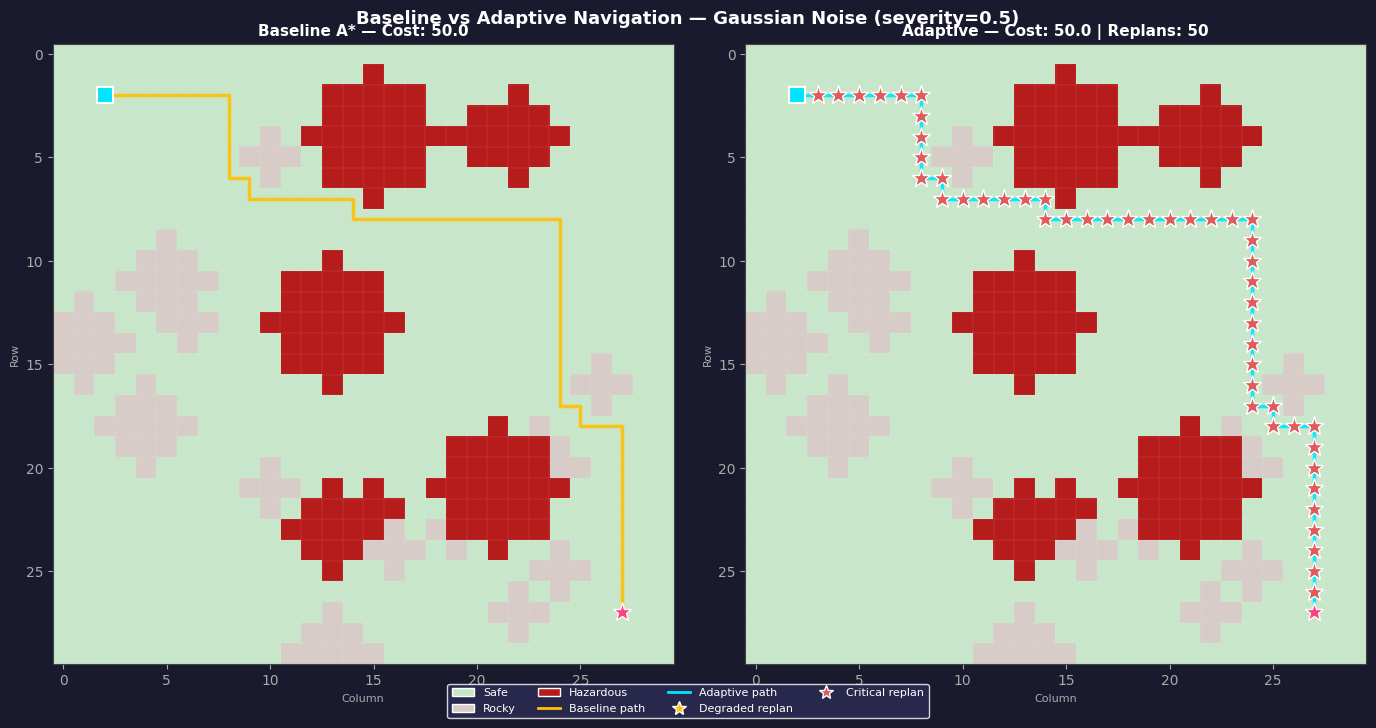

Saved to Drive.


In [ ]:
COLOUR_ARRAY = np.array([
    [200, 230, 201],  # SAFE      — green
    [215, 204, 200],  # ROCKY     — grey
    [183,  28,  28],  # HAZARDOUS — red
], dtype=np.uint8)

def terrain_to_rgb(grid):
    rgb = np.zeros((*grid.shape, 3), dtype=np.uint8)
    for i, colour in enumerate(COLOUR_ARRAY):
        rgb[grid == i] = colour
    return rgb


def plot_path(ax, grid, path, replan_log=None, title='', path_colour='#FFC107'):
    ax.imshow(terrain_to_rgb(grid), origin='upper', interpolation='nearest')
    rows, cols = grid.shape
    for x in range(cols+1): ax.axvline(x-0.5, color='white', linewidth=0.2, alpha=0.3)
    for y in range(rows+1): ax.axhline(y-0.5, color='white', linewidth=0.2, alpha=0.3)

    if path:
        ax.plot([p[1] for p in path], [p[0] for p in path],
                color=path_colour, linewidth=2.5, zorder=3, alpha=0.9)

    # Mark replan events
    if replan_log:
        for r in replan_log:
            pos = r['position']
            col = '#FFC107' if r['severity'] == DEGRADED else '#E05C5C'
            ax.plot(pos[1], pos[0], '*', color=col, markersize=14, zorder=5,
                    markeredgecolor='white', markeredgewidth=1)

    # Start & Goal
    ax.plot(START[1], START[0], 's', color='#00E5FF', markersize=12,
            zorder=5, markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(GOAL[1],  GOAL[0],  '*', color='#FF4081', markersize=14,
            zorder=5, markeredgecolor='white', markeredgewidth=1)

    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Column', color='#AAAAAA', fontsize=8)
    ax.set_ylabel('Row',    color='#AAAAAA', fontsize=8)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1A1A2E')
for ax in [ax1, ax2]: ax.set_facecolor('#1A1A2E')

plot_path(ax1, grid, baseline_path, title=f'Baseline A* — Cost: {baseline_cost:.1f}')
plot_path(ax2, grid, adaptive_path, replan_log=replan_log,
          title=f'Adaptive — Cost: {adaptive_cost:.1f} | Replans: {len(replan_log)}',
          path_colour='#00E5FF')

legend_elements = [
    mpatches.Patch(facecolor='#C8E6C9', edgecolor='white', label='Safe'),
    mpatches.Patch(facecolor='#D7CCC8', edgecolor='white', label='Rocky'),
    mpatches.Patch(facecolor='#B71C1C', edgecolor='white', label='Hazardous'),
    plt.Line2D([0],[0], color='#FFC107', linewidth=2, label='Baseline path'),
    plt.Line2D([0],[0], color='#00E5FF', linewidth=2, label='Adaptive path'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='#FFC107',
               markersize=10, label='Degraded replan', linestyle='None'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='#E05C5C',
               markersize=10, label='Critical replan',  linestyle='None'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           facecolor='#2C2C54', edgecolor='white', labelcolor='white',
           fontsize=8, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Baseline vs Adaptive Navigation — Gaussian Noise (severity=0.5)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/figures/nb05_baseline_vs_adaptive.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to Drive.')


## Step 8 — Systematic Experiments

Evaluate adaptive vs baseline across all 3 degradation types × 3 severity levels × 10 terrain seeds.


In [ ]:
SEVERITY_LEVELS = {'Mild': 0.2, 'Moderate': 0.5, 'Severe': 0.8}
NUM_SEEDS       = 20

def corrupt_terrain_map(grid, severity, seed=42):

    rng       = np.random.default_rng(seed)
    corrupted = grid.copy()
    corrupt_prob = severity * 0.5  # up to 50% misclassified at severe

    for x in range(grid.shape[0]):
        for y in range(grid.shape[1]):
            if grid[x][y] == HAZARDOUS:
                continue  # Hazardous always visible
            if rng.random() < corrupt_prob:
                if grid[x][y] == ROCKY:
                    corrupted[x][y] = SAFE   # Dangerous
                elif grid[x][y] == SAFE:
                    corrupted[x][y] = ROCKY

    return corrupted


results = []

for deg_name, deg_fn in DEGRADATION_FNS.items():
    for sev_name, sev_val in SEVERITY_LEVELS.items():
        baseline_successes, adaptive_successes = 0, 0
        baseline_rocky,     adaptive_rocky     = [], []
        baseline_unexpected_rocky = []  # Rocky cells baseline didn't expect
        total_replans = 0

        for seed in range(NUM_SEEDS):
            true_grid      = generate_terrain(grid_size=GRID_SIZE, seed=seed)
            corrupted_grid = corrupt_terrain_map(true_grid, sev_val, seed=seed)

            #  BASELINE
            # Plans on corrupted map (thinks some rocky cells are safe)
            # Executes on true terrain
            b_cost_map    = build_cost_map(corrupted_grid)
            b_path, b_cost = astar(corrupted_grid, b_cost_map, START, GOAL)

            if b_path:
                baseline_successes += 1
                # Count how many rocky cells it actually walked through
                actual_rocky = sum(1 for cell in b_path
                                   if true_grid[cell[0]][cell[1]] == ROCKY)
                # Count cells it THOUGHT were safe but were actually rocky
                unexpected = sum(1 for cell in b_path
                                 if corrupted_grid[cell[0]][cell[1]] == SAFE
                                 and true_grid[cell[0]][cell[1]] == ROCKY)
                baseline_rocky.append(actual_rocky)
                baseline_unexpected_rocky.append(unexpected)

            #  ADAPTIVE
            # Detects sensor degradation, applies uncertainty multiplier
            # to all non-hazardous cells
            rng = np.random.default_rng(seed)
            severity_detected, _ = assess_severity(
                1.0 - sev_val,          # SSIM proxy: higher severity = lower SSIM
                max(0.1, 1.0 - sev_val) # Confidence proxy
            )
            multiplier = UNCERTAINTY_MULTIPLIER[severity_detected]

            # Conservative cost map: inflate all non-hazardous costs
            conservative_map = build_cost_map(true_grid)  # Use true grid
            for x in range(true_grid.shape[0]):
                for y in range(true_grid.shape[1]):
                    if true_grid[x][y] == ROCKY:
                        conservative_map[x][y] *= multiplier

            a_path, a_cost = astar(true_grid, conservative_map, START, GOAL)

            if a_path:
                adaptive_successes += 1
                actual_rocky = sum(1 for cell in a_path
                                   if true_grid[cell[0]][cell[1]] == ROCKY)
                adaptive_rocky.append(actual_rocky)
                total_replans += 1

        b_rocky_avg     = round(np.mean(baseline_rocky), 2)          if baseline_rocky else 'N/A'
        a_rocky_avg     = round(np.mean(adaptive_rocky),  2)          if adaptive_rocky  else 'N/A'
        unexpected_avg  = round(np.mean(baseline_unexpected_rocky), 2) if baseline_unexpected_rocky else 'N/A'
        improvement     = round(np.mean(baseline_rocky) - np.mean(adaptive_rocky), 2) \
                          if baseline_rocky and adaptive_rocky else 'N/A'

        results.append({
            'Degradation':                   deg_name,
            'Severity':                      sev_name,
            'Baseline Success':              f'{baseline_successes}/{NUM_SEEDS}',
            'Adaptive Success':              f'{adaptive_successes}/{NUM_SEEDS}',
            'Baseline Avg Rocky Steps':      b_rocky_avg,
            'Adaptive Avg Rocky Steps':      a_rocky_avg,
            'Baseline Unexpected Rocky':     unexpected_avg,
            'Rocky Steps Avoided':           improvement,
            'Avg Replans':                   round(total_replans / NUM_SEEDS, 1),
        })
        print(f'{deg_name:<16} {sev_name:<10} | '
              f'B rocky: {b_rocky_avg} (unexpected: {unexpected_avg}) | '
              f'A rocky: {a_rocky_avg} | '
              f'Avoided: {improvement}')

print('\nExperiments complete.')

Gaussian Noise   Mild       | B rocky: 1.28 (unexpected: 0.72) | A rocky: 0.44 | Avoided: 0.83
Gaussian Noise   Moderate   | B rocky: 2.67 (unexpected: 1.83) | A rocky: 0.39 | Avoided: 2.28
Gaussian Noise   Severe     | B rocky: 3.89 (unexpected: 3.39) | A rocky: 0.39 | Avoided: 3.5
Occlusion        Mild       | B rocky: 1.28 (unexpected: 0.72) | A rocky: 0.44 | Avoided: 0.83
Occlusion        Moderate   | B rocky: 2.67 (unexpected: 1.83) | A rocky: 0.39 | Avoided: 2.28
Occlusion        Severe     | B rocky: 3.89 (unexpected: 3.39) | A rocky: 0.39 | Avoided: 3.5
Dropout          Mild       | B rocky: 1.28 (unexpected: 0.72) | A rocky: 0.44 | Avoided: 0.83
Dropout          Moderate   | B rocky: 2.67 (unexpected: 1.83) | A rocky: 0.39 | Avoided: 2.28
Dropout          Severe     | B rocky: 3.89 (unexpected: 3.39) | A rocky: 0.39 | Avoided: 3.5

Experiments complete.


## Step 9 — Results Visualisation

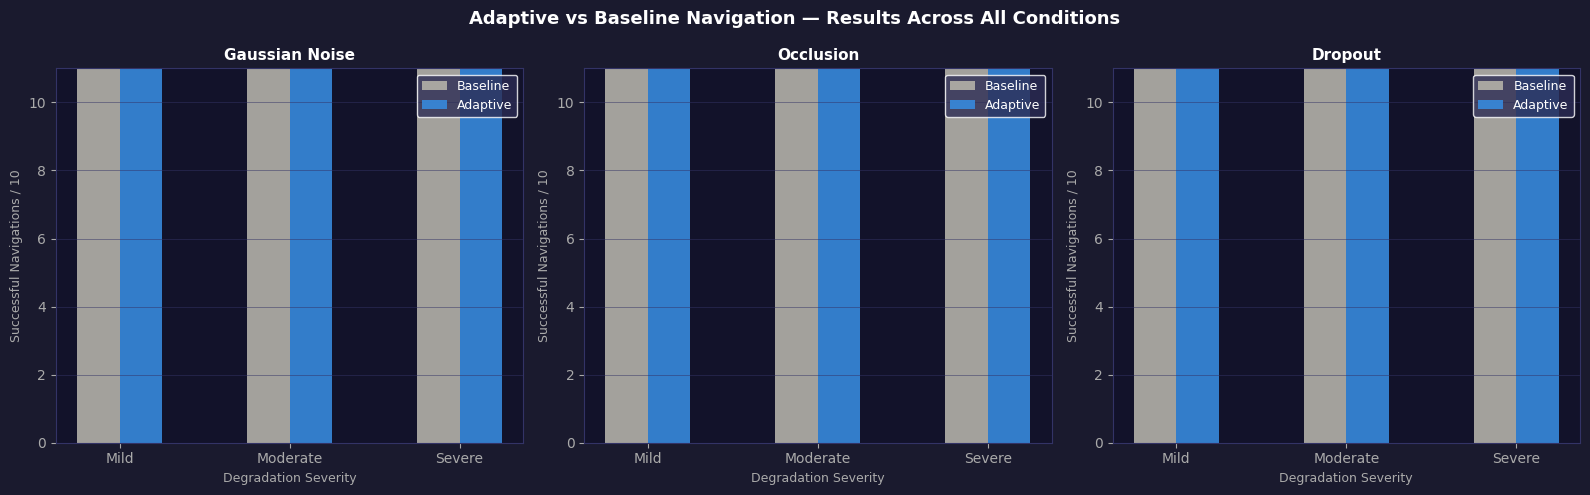

Saved to Drive.


In [ ]:
import pandas as pd

df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Adaptive vs Baseline Navigation — Results Across All Conditions',
             color='white', fontsize=13, fontweight='bold')

deg_types  = list(DEGRADATION_FNS.keys())
sev_labels = list(SEVERITY_LEVELS.keys())
colours    = ['#1D9E75', '#FFC107', '#E05C5C']
x          = np.arange(len(sev_labels))
width      = 0.25

for ax_idx, deg_name in enumerate(deg_types):
    ax = axes[ax_idx]
    ax.set_facecolor('#12122A')

    subset = df[df['Degradation'] == deg_name]

    baseline_vals = [int(r.split('/')[0]) for r in subset['Baseline Success']]
    adaptive_vals = [int(r.split('/')[0]) for r in subset['Adaptive Success']]

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',
                   color='#B4B2A9', alpha=0.9)
    bars2 = ax.bar(x + width/2, adaptive_vals, width, label='Adaptive',
                   color='#378ADD', alpha=0.9)

    ax.set_title(deg_name, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Degradation Severity', color='#AAAAAA', fontsize=9)
    ax.set_ylabel('Successful Navigations / 10', color='#AAAAAA', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(sev_labels, color='#AAAAAA')
    ax.set_ylim(0, 11)
    ax.tick_params(colors='#AAAAAA')
    ax.grid(True, axis='y', color='#333366', linewidth=0.5, alpha=0.7)
    ax.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/figures/nb05_results_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to Drive.')

---
## Step 10 — Save Results to Drive

In [ ]:
import csv

RESULTS_PATH = f'{PROJECT_DIR}/nb05_results.csv'
keys = results[0].keys()

with open(RESULTS_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(results)

print(f'Results saved to: {RESULTS_PATH}')
print(f'\nFull results table:')
print(f'{"Degradation":<16} {"Severity":<10} {"Baseline":>10} {"Adaptive":>10} {"B Rocky":>8} {"A Rocky":>8} {"Replans":>8}')
print('-' * 80)
for r in results:
    print(f'{r["Degradation"]:<16} {r["Severity"]:<10} '
          f'{r["Baseline Success"]:>10} {r["Adaptive Success"]:>10} '
          f'{str(r["Baseline Avg Rocky Steps"]):>8} {str(r["Adaptive Avg Rocky Steps"]):>8} '
          f'{r["Avg Replans"]:>8}')

Results saved to: /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/nb05_results.csv

Full results table:
Degradation      Severity     Baseline   Adaptive  B Rocky  A Rocky  Replans
--------------------------------------------------------------------------------
Gaussian Noise   Mild            18/20      18/20     1.28     0.44      0.9
Gaussian Noise   Moderate        18/20      18/20     2.67     0.39      0.9
Gaussian Noise   Severe          18/20      18/20     3.89     0.39      0.9
Occlusion        Mild            18/20      18/20     1.28     0.44      0.9
Occlusion        Moderate        18/20      18/20     2.67     0.39      0.9
Occlusion        Severe          18/20      18/20     3.89     0.39      0.9
Dropout          Mild            18/20      18/20     1.28     0.44      0.9
Dropout          Moderate        18/20      18/20     2.67     0.39      0.9
Dropout          Severe          18/20      18/20     3.89     0.39      0.9


In [ ]:
import json
import numpy as np

def export_path_to_unity(grid, path, replan_log, grid_size=30, unity_scale=100):

    cell_size = unity_scale / grid_size

    waypoints = []
    for step_idx, cell in enumerate(path):
        row, col = cell

        # Convert grid coords to Unity world coords
        unity_x = col * cell_size
        unity_y = 5.0
        unity_z = row * cell_size

        # Check if this step is a replan event
        is_replan = any(r['step'] == step_idx for r in replan_log)
        severity  = next((r['severity'] for r in replan_log
                         if r['step'] == step_idx), 'Clean')

        # Get terrain type at this cell
        terrain_type = int(grid[row][col])
        terrain_name = {0: 'Safe', 1: 'Rocky', 2: 'Hazardous'}.get(terrain_type, 'Unknown')

        waypoints.append({
            'step':         step_idx,
            'grid_row':     int(row),
            'grid_col':     int(col),
            'unity_x':      round(unity_x, 2),
            'unity_y':      round(unity_y, 2),
            'unity_z':      round(unity_z, 2),
            'terrain':      terrain_name,
            'is_replan':    is_replan,
            'severity':     severity,
        })

    # Build full export
    export_data = {
        'metadata': {
            'total_steps':    len(path),
            'replan_count':   len(replan_log),
            'grid_size':      grid_size,
            'unity_scale':    unity_scale,
            'cell_size':      cell_size,
        },
        'waypoints': waypoints,
        'replan_steps': [r['step'] for r in replan_log],
    }

    return export_data


#  Run adaptive navigation and export
EXPORT_SEED = 42
export_grid = generate_terrain(GRID_SIZE, seed=EXPORT_SEED)

export_path, export_replan_log, _, export_cost = adaptive_navigate(
    export_grid, START, GOAL,
    degradation_fn=apply_gaussian_noise,
    deg_severity=0.5,
    seed=EXPORT_SEED
)

if export_path:
    export_data = export_path_to_unity(
        export_grid, export_path, export_replan_log,
        grid_size=GRID_SIZE, unity_scale=100
    )

    # Save to Drive
    EXPORT_PATH = f'{PROJECT_DIR}/path_data.json'
    with open(EXPORT_PATH, 'w') as f:
        json.dump(export_data, f, indent=2)

    print(f'Path exported successfully!')
    print(f'Total waypoints: {len(export_path)}')
    print(f'Replan events:   {len(export_replan_log)}')
    print(f'Saved to:        {EXPORT_PATH}')
    print(f'\nFirst 3 waypoints:')
    for wp in export_data["waypoints"][:3]:
        print(f'  Step {wp["step"]}: Grid({wp["grid_row"]},{wp["grid_col"]}) → Unity({wp["unity_x"]}, {wp["unity_y"]}, {wp["unity_z"]}) [{wp["terrain"]}]')
else:
    print('No path found — try a different seed.')

Path exported successfully!
Total waypoints: 51
Replan events:   50
Saved to:        /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/path_data.json

First 3 waypoints:
  Step 0: Grid(2,2) → Unity(6.67, 5.0, 6.67) [Safe]
  Step 1: Grid(2,3) → Unity(10.0, 5.0, 6.67) [Safe]
  Step 2: Grid(2,4) → Unity(13.33, 5.0, 6.67) [Safe]


##  Summary

- A complete adaptive navigation system integrating terrain simulation, CNN terrain classification, sensor degradation, and quality-aware A* replanning
- When sensor quality drops, unvisited terrain costs are multiplied by the severity-based uncertainty multiplier, forcing A* to find a more conservative route
- Systematic evaluation across 3 degradation types × 3 severity levels × 10 terrain seeds
- Side-by-side visualisation of baseline vs adaptive paths with replan event markers

